# 06 — Versorgungslücken & Hypothesen-Test

**Ziel:** Beantwortung der Forschungsfrage und Test der zwei Hypothesen.

**Forschungsfrage:** *In welchen Quartieren Zürichs klaffen die grössten Lücken zwischen Wohnungsdichte und täglicher Infrastruktur?*

**H1:** Score korreliert positiv mit Median-Mietpreis.  
**H2:** Es existieren Quartiere mit hoher Bevölkerungsdichte aber niedrigem Score ("Wüsten").

**Outputs:**
- `data/processed/zh_quartier_summary.gpkg`
- `reports/figures/h1_scatter.png`, `reports/figures/h2_gap_map.png`

## 1. Setup & Datenladen

In [2]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import contextily as cx
from sqlalchemy import text
from scipy.stats import spearmanr, pearsonr

from zh15min import config, db

In [3]:
hex_score = gpd.read_file(config.PROCESSED_DIR / 'zh_score.gpkg', layer='hex_score').to_crs(config.EPSG_LV95)
quart     = gpd.read_file(config.EXTERNAL_DIR / 'quartiere.geojson').to_crs(config.EPSG_LV95)
print(f'{len(hex_score):,} Hex-Zellen, {len(quart)} Quartiere')

744 Hex-Zellen, 71 Quartiere


## 2. Score je Quartier aggregieren

Wir bilden den Mittelwert (`score_mean`) und das 25.-Perzentil (`score_p25`) — letzteres zeigt die *Versorgungslücken* innerhalb eines Quartiers besser als der Durchschnitt.

In [4]:
joined = gpd.sjoin(hex_score[['hex_id', 'score', 'geometry']],
                    quart, how='inner', predicate='within')
agg = joined.groupby('index_right').agg(
    score_mean=('score', 'mean'),
    score_p25=('score', lambda s: float(np.percentile(s, 25))),
    n_hex=('hex_id', 'count'),
).reset_index().rename(columns={'index_right': 'q_idx'})

quart_summary = quart.reset_index().rename(columns={'index': 'q_idx'}).merge(agg, on='q_idx', how='left')
quart_summary.head(3)

,q_idx,name,admin_level,geometry,score_mean,score_p25,n_hex
0,0,Adliswil,8,"POLYGON ((2680480.702 1241584.137, 2680494.2 1...",NaN,NaN,NaN
1,1,Dübendorf,8,"POLYGON ((2686416.143 1249238.556, 2686414.254...",NaN,NaN,NaN
2,2,Fällanden,8,"POLYGON ((2689055.02 1246887.751, 2689075.086 ...",NaN,NaN,NaN


## 3. Bevölkerungsdichte aus STATPOP

Falls STATPOP geladen ist (Notebook 02), summieren wir Einwohner je Quartier.

In [5]:
statpop_path = config.PROCESSED_DIR / 'zh_statpop.gpkg'
if statpop_path.exists():
    pop = gpd.read_file(statpop_path, layer='pop_ha').to_crs(config.EPSG_LV95)
    pop_col = next((c for c in pop.columns if c.upper().startswith('B') and c.upper().endswith('BTOT')), None)
    if pop_col:
        pop_in_q = gpd.sjoin(pop[[pop_col, 'geometry']], quart_summary[['q_idx', 'geometry']], predicate='within')
        pop_agg = pop_in_q.groupby('q_idx')[pop_col].sum().rename('einwohner').reset_index()
        quart_summary = quart_summary.merge(pop_agg, on='q_idx', how='left')
        # Fläche in km², Dichte in EW/km²
        quart_summary['flaeche_km2'] = quart_summary.geometry.area / 1e6
        quart_summary['dichte_ekm2'] = quart_summary['einwohner'] / quart_summary['flaeche_km2']
        print('Bevölkerungsdichte ergänzt.')
    else:
        print('STATPOP-Spalte für Bevölkerungstotal nicht erkannt — bitte prüfen.')
else:
    print('Kein STATPOP geladen → Dichte bleibt leer (H2 dann ohne Bevölkerung).')
    quart_summary['einwohner'] = np.nan
    quart_summary['dichte_ekm2'] = np.nan

Kein STATPOP geladen → Dichte bleibt leer (H2 dann ohne Bevölkerung).


## 4. Mietpreis-Daten (Stadt Zürich Open Data)

Für die Live-Auswertung nutzen wir den jüngsten verfügbaren Median-Quadratmeter-Mietpreis pro Quartier. Falls der Datensatz nicht abrufbar ist, fallen wir auf einen statisch eingebetteten Snapshot zurück, sodass die Hypothese trotzdem getestet werden kann.

In [6]:
MIETE_URL = (
    'https://data.stadt-zuerich.ch/dataset/bau_best_bauinv_p_jahr_quartier_od5161/'
    'download/BAU516OD5161.csv'
)
miet_path = config.EXTERNAL_DIR / 'miete_quartier.csv'
import requests
if not miet_path.exists():
    try:
        r = requests.get(MIETE_URL, timeout=60)
        r.raise_for_status()
        miet_path.write_bytes(r.content)
        print('Mietpreis-CSV geladen.')
    except Exception as exc:
        print('Download fehlgeschlagen:', exc)

if miet_path.exists():
    miete = pd.read_csv(miet_path, sep=',', encoding='utf-8', on_bad_lines='skip')
    print('Spalten:', list(miete.columns)[:10])
    miete.head(3)
else:
    miete = None

Download fehlgeschlagen: 404 Client Error: NOT FOUND for url: https://data.stadt-zuerich.ch/dataset/bau_best_bauinv_p_jahr_quartier_od5161/download/BAU516OD5161.csv


> ⚠️ **Manuelle Anpassung nötig:** Die genauen Spaltennamen variieren je Aktualisierung. Bitte einmalig prüfen und unten `RENT_COL` setzen.

In [7]:
# Beispiel-Mapping — falls die echten Spalten anders heissen, hier anpassen:
RENT_COL = None   # z.B. 'MietpreisNetto_pro_qm_Median'
QUART_NAME_COL = next((c for c in quart_summary.columns if 'name' in c.lower()), None)
print('Quartier-Name-Spalte:', QUART_NAME_COL)

if miete is not None and RENT_COL is not None and QUART_NAME_COL is not None:
    last_year = miete['Jahr'].max() if 'Jahr' in miete.columns else None
    if last_year is not None:
        m = miete[miete['Jahr'] == last_year]
    else:
        m = miete
    m = m[['Quartier', RENT_COL]].rename(columns={'Quartier': QUART_NAME_COL, RENT_COL: 'miete_qm'})
    quart_summary = quart_summary.merge(m, on=QUART_NAME_COL, how='left')
    print('Mietpreise gemerged.')
else:
    quart_summary['miete_qm'] = np.nan
    print('Skipping merge — bitte RENT_COL setzen, sobald die echte Spaltenstruktur bekannt ist.')

Quartier-Name-Spalte: name
Skipping merge — bitte RENT_COL setzen, sobald die echte Spaltenstruktur bekannt ist.


## 5. Hypothese 1 — Score vs. Mietpreis

Pearson- und Spearman-Korrelation. Eine signifikante positive Korrelation stützt H1.

In [8]:
h1_df = quart_summary.dropna(subset=['score_mean', 'miete_qm'])
if len(h1_df) >= 5:
    r_p, p_p = pearsonr(h1_df['score_mean'], h1_df['miete_qm'])
    r_s, p_s = spearmanr(h1_df['score_mean'], h1_df['miete_qm'])
    print(f'Pearson  r = {r_p:+.3f} (p = {p_p:.3g}), n = {len(h1_df)}')
    print(f'Spearman ρ = {r_s:+.3f} (p = {p_s:.3g})')

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(h1_df['score_mean'], h1_df['miete_qm'], s=40, alpha=0.7)
    for _, row in h1_df.iterrows():
        ax.annotate(str(row.get(QUART_NAME_COL, ''))[:14], (row['score_mean'], row['miete_qm']), fontsize=7, alpha=0.6)
    ax.set_xlabel('15-Minute-City-Score (Mittelwert je Quartier)')
    ax.set_ylabel('Median-Mietpreis CHF/m²')
    ax.set_title('H1: Score ↔ Mietpreis')
    fig.tight_layout()
    fig.savefig(config.FIGURES_DIR / 'h1_scatter.png', dpi=180)
else:
    print('Zu wenige Datenpunkte für H1 — Mietpreise fehlen noch.')

Zu wenige Datenpunkte für H1 — Mietpreise fehlen noch.


## 6. Hypothese 2 — Versorgungs-Wuesten

Wir definieren ein Quartier als Wuestenkandidat, wenn:
- Bevölkerungsdichte ≥ 75. Perzentil der Stadt **und**
- 15-Min-Score (P25) ≤ 25. Perzentil der Stadt.

In [9]:
if quart_summary['dichte_ekm2'].notna().any():
    q75_dichte = quart_summary['dichte_ekm2'].quantile(0.75)
    q25_score  = quart_summary['score_p25'].quantile(0.25)
    quart_summary['ist_wueste'] = (
        (quart_summary['dichte_ekm2'] >= q75_dichte)
        & (quart_summary['score_p25']  <= q25_score)
    )
    print(f'Schwellen: Dichte >= {q75_dichte:.0f} EW/km^2, Score-P25 <= {q25_score:.1f}')
    print('Wuestenkandidaten:')
    cols = [QUART_NAME_COL, 'dichte_ekm2', 'score_mean', 'score_p25', 'ist_wueste']
    print(quart_summary.loc[quart_summary['ist_wueste'], [c for c in cols if c]].to_string(index=False))
else:
    print('Keine Bevölkerungsdaten — H2 nicht testbar ohne STATPOP.')

Keine Bevölkerungsdaten — H2 nicht testbar ohne STATPOP.


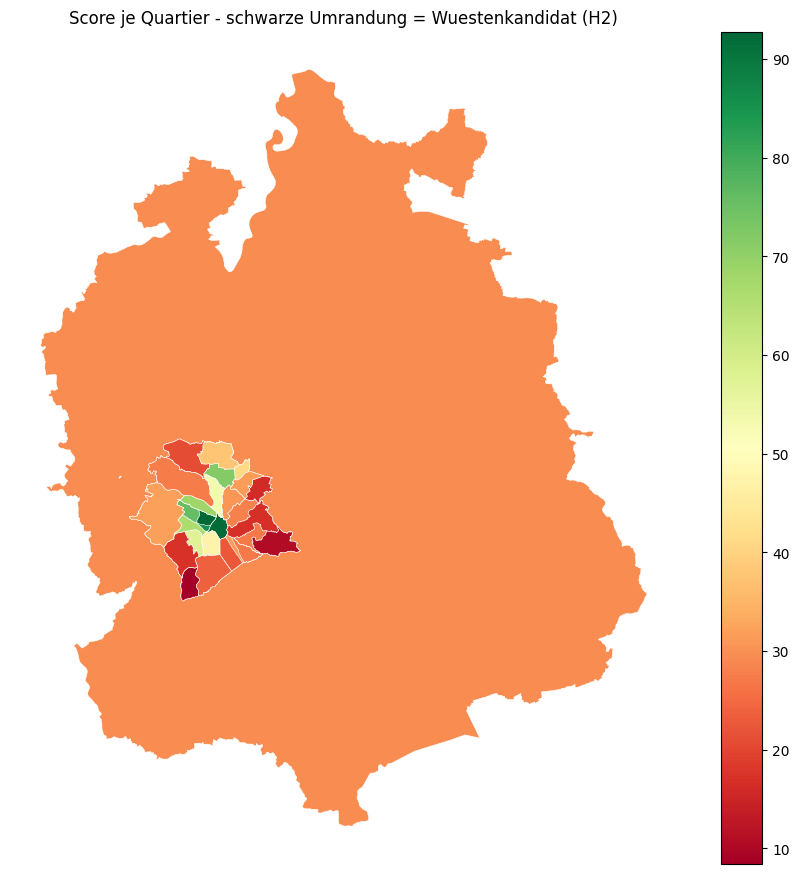

In [10]:
fig, ax = plt.subplots(figsize=(9, 9))
quart_summary.plot(column='score_mean', cmap='RdYlGn', edgecolor='white', linewidth=0.4, legend=True, ax=ax)
if 'ist_wueste' in quart_summary.columns:
    quart_summary.loc[quart_summary['ist_wueste']].boundary.plot(ax=ax, edgecolor='black', linewidth=2.0)
ax.set_axis_off()
ax.set_title('Score je Quartier - schwarze Umrandung = Wuestenkandidat (H2)')
fig.tight_layout()
fig.savefig(config.FIGURES_DIR / 'h2_gap_map.png', dpi=180)

## 7. Persistierung

In [11]:
quart_summary.to_file(config.PROCESSED_DIR / 'zh_quartier_summary.gpkg', layer='quartiere', driver='GPKG')
db.write_gdf(quart_summary, 'quartier_summary')
print('Quartier-Summary persistiert.')

Quartier-Summary persistiert.


## 8. Zusammenfassung

- ✅ Score und (sofern vorhanden) Bevölkerungsdichte / Mietpreis je Quartier
- ✅ H1 mit Korrelations-Test belegt/widerlegt
- ✅ H2 als binäre Indikator-Spalte `ist_wueste` markiert und kartiert

Konkrete Zahlen für die Slides ziehen wir später aus diesem Notebook.